In [52]:
from PIL import Image, ImageDraw
import drawsvg as draw
import shapely.geometry as Geom
import numpy as np

In [2]:
def make_bezier(xys: list[tuple]):
    # xys should be a sequence of 2-tuples (Bezier control points)
    n = len(xys)
    combinations = pascal_row(n-1)
    def bezier(ts):
        # This uses the generalized formula for bezier curves
        # http://en.wikipedia.org/wiki/B%C3%A9zier_curve#Generalization
        result = []
        for t in ts:
            tpowers = (t**i for i in range(n))
            upowers = reversed([(1-t)**i for i in range(n)])
            coefs = [c*a*b for c, a, b in zip(combinations, tpowers, upowers)]
            result.append(
                tuple(sum([coef*p for coef, p in zip(coefs, ps)]) for ps in zip(*xys)))
        return result
    return bezier

def pascal_row(n, memo={}):
    # This returns the nth row of Pascal's Triangle
    if n in memo:
        return memo[n]
    result = [1]
    x, numerator = 1, n
    for denominator in range(1, n//2+1):
        # print(numerator,denominator,x)
        x *= numerator
        x /= denominator
        result.append(x)
        numerator -= 1
    if n&1 == 0:
        # n is even
        result.extend(reversed(result[:-1]))
    else:
        result.extend(reversed(result))
    memo[n] = result
    return result

In [95]:
def DrawStroke(canvas: Image, strokepath: list[tuple], thickness: float = 3.0):
    _active_canvas = canvas

    if not hasattr(_active_canvas, "margin"): raise AttributeError('canvas does not have attribute "margin"')
    if not hasattr(_active_canvas, "subdivision"): raise AttributeError('canvas does not have attribute "subdivision"')

    _canvas_area = tuple(x - canvas.margin * 2 for x in canvas.size)
    _canvas_fraction = tuple(x/canvas.subdivision for x in _canvas_area)

    _scaled_strokepath = []
    for i, x in enumerate(strokepath):
        _scaled_strokepath.append(tuple((canvas.margin + (x[n] * _canvas_fraction[n]) - (_canvas_fraction[n]/2)) for n in [0,1]))

    _draw = ImageDraw.Draw(_active_canvas)

    #generate n points along the bezier curve
    n_points = 128
    _bezier_points = make_bezier(_scaled_strokepath)([t/n_points for t in range(n_points + 1)])

    for i, centre in enumerate(_bezier_points):
        _cur_thickness = (thickness - 1) * (len(_bezier_points) - i)/(len(_bezier_points)) + 1

        _draw.ellipse((centre[0] - _cur_thickness,
                       centre[1] - _cur_thickness,
                       centre[0] + _cur_thickness,
                       centre[1] + _cur_thickness),
                       fill=(0,0,0,255))
    return _active_canvas

def DrawCharacter(canvas: Image, strokes: list[list[tuple]], thickness: float | list[float] = 3.0):
    if type(thickness) is list:
        if len(thickness) > 1 and len(thickness) != len(strokes):
            raise ValueError('strokes and thickness must be the same length!')

    _active_canvas = canvas

    for idx, stroke in enumerate(strokes):
        if type(thickness) is list:
            _cur_thickness = thickness[idx]
        else:
            _cur_thickness = thickness
        _active_canvas = DrawStroke(_active_canvas, stroke, _cur_thickness)

    return _active_canvas

In [4]:
def get_font_template_pos(place: int):
    _margin_init = 9
    _margin_width = 19
    return ((np.mod(place, 16) * (64 + _margin_width)) + _margin_init, int(np.floor(place/16) * (64 + _margin_width)) + _margin_init)

In [5]:
character_dict = {}

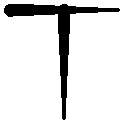

In [103]:
place = 1
canvas = Image.new(mode = "RGBA", size = (128,128), color = (255,255,255,255))
canvas.margin = 1
canvas.subdivision = 7

DrawCharacter(canvas, [[(4,1),(4,7)],[(1,1),(7,1)]], 6)

character_dict[place] = canvas

canvas

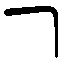

In [7]:
place = 2
canvas = Image.new(mode = "RGBA", size = (64,64), color = (0,0,0,0))
canvas.margin = 5
canvas.subdivision = 11

DrawStroke(canvas, [(1,2),(11,1),(11,1),(11,1),(11,11)])

character_dict[place] = canvas

canvas

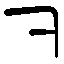

In [8]:
place = 3
canvas = Image.new(mode = "RGBA", size = (64,64), color = (0,0,0,0))
canvas.margin = 5
canvas.subdivision = 11

DrawStroke(canvas, [(1,2),(11,1),(11,1),(11,1),(11,11)])
DrawStroke(canvas, [(6,6),(11,6)])

character_dict[place] = canvas

canvas

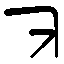

In [9]:
place = 4
canvas = Image.new(mode = "RGBA", size = (64,64), color = (0,0,0,0))
canvas.margin = 5
canvas.subdivision = 11

DrawStroke(canvas, [(1,2),(11,1),(11,1),(11,1),(11,11)])
DrawStroke(canvas, [(6,6),(11,6),(11,6),(11,6),(6,11)])

character_dict[place] = canvas

canvas

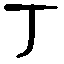

In [10]:
place = 5
canvas = Image.new(mode = "RGBA", size = (64,64), color = (0,0,0,0))
canvas.margin = 5
canvas.subdivision = 11

DrawStroke(canvas, [(1,1),(11,1)])
DrawStroke(canvas, [(6,1),(6,10),(6,10),(3,11)])

character_dict[place] = canvas

canvas

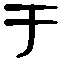

In [11]:
place = 6
canvas = Image.new(mode = "RGBA", size = (64,64), color = (0,0,0,0))
canvas.margin = 5
canvas.subdivision = 11

DrawStroke(canvas, [(1,1),(11,1)])
DrawStroke(canvas, [(1,4),(11,4)])
DrawStroke(canvas, [(6,1),(6,10),(6,10),(3,11)])

character_dict[place] = canvas

canvas

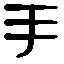

In [12]:
place = 7
canvas = Image.new(mode = "RGBA", size = (64,64), color = (0,0,0,0))
canvas.margin = 5
canvas.subdivision = 11

DrawStroke(canvas, [(1,1),(11,1)])
DrawStroke(canvas, [(1,4),(11,4)])
DrawStroke(canvas, [(1,7),(11,7)])
DrawStroke(canvas, [(6,1),(6,10),(6,10),(3,11)])

character_dict[place] = canvas

canvas

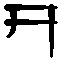

In [13]:
place = 8
canvas = Image.new(mode = "RGBA", size = (64,64), color = (0,0,0,0))
canvas.margin = 5
canvas.subdivision = 11

DrawStroke(canvas, [(1,1),(11,1)])
DrawStroke(canvas, [(1,4),(11,4)])
DrawStroke(canvas, [(2,1),(3,6),(1,7)])
DrawStroke(canvas, [(10,1),(10,11)])

character_dict[place] = canvas

canvas

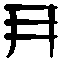

In [14]:
place = 9
canvas = Image.new(mode = "RGBA", size = (64,64), color = (0,0,0,0))
canvas.margin = 5
canvas.subdivision = 11

DrawStroke(canvas, [(1,1),(11,1)])
DrawStroke(canvas, [(1,4),(11,4)])
DrawStroke(canvas, [(1,7),(11,7)])
DrawStroke(canvas, [(2,1),(3,10),(1,11)])
DrawStroke(canvas, [(10,1),(10,11)])

character_dict[place] = canvas

canvas

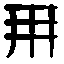

In [15]:
place = 10
canvas = Image.new(mode = "RGBA", size = (64,64), color = (0,0,0,0))
canvas.margin = 5
canvas.subdivision = 11

DrawStroke(canvas, [(1,1),(11,1)])
DrawStroke(canvas, [(1,4),(11,4)])
DrawStroke(canvas, [(1,7),(11,7)])
DrawStroke(canvas, [(2,1),(3,10),(1,11)])
DrawStroke(canvas, [(6,1),(6,11)])
DrawStroke(canvas, [(10,1),(10,11)])

character_dict[place] = canvas

canvas

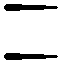

In [16]:
place = 11
canvas = Image.new(mode = "RGBA", size = (64,64), color = (0,0,0,0))
canvas.margin = 5
canvas.subdivision = 11

DrawStroke(canvas, [(1,1),(11,1)])
DrawStroke(canvas, [(1,11),(11,11)])

character_dict[place] = canvas

canvas

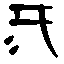

In [17]:
#34
place = 34
canvas = Image.new(mode = "RGBA", size = (64,64), color = (0,0,0,0))
canvas.margin = 5
canvas.subdivision = 11

DrawStroke(canvas, [(2,1),(10,1)])
DrawStroke(canvas, [(2,4),(10,4)])
DrawStroke(canvas, [(3,1),(3,4)])
DrawStroke(canvas, [(8,1),(8,7),(11,11)])
DrawStroke(canvas, [(1,8),(2,7)])
DrawStroke(canvas, [(2,10),(3,9)])

character_dict[place] = canvas

canvas

In [18]:
def add_to_font_template(im: Image, place: int, font_template: Image = Image.open("font_template.png")):
    font_template.paste(im, get_font_template_pos(place))
    return font_template

In [19]:
out = Image.open("font_template.png")

for k in character_dict.keys():
    out = add_to_font_template(character_dict[k], k, out)

out.save("test_overwrite.png")